In [1]:
import pandas as pd
import numpy as np

# The file has no header, fields are separated by multiple spaces and missing values are encoded as 'N'
column_names = [
    "Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
    "Nickel_Ni", "Chromium_Cr", "Molybdenum_Mo", "Vanadium_V", "Copper_Cu",
    "Cobalt_Co", "Tungsten_W", "Oxygen_O_ppm", "Titanium_Ti_ppm", "Nitrogen_N_ppm",
    "Aluminium_Al_ppm", "Boron_B_ppm", "Niobium_Nb_ppm", "Tin_Sn_ppm", "Arsenic_As_ppm",
    "Antimony_Sb_ppm", "Current_A", "Voltage_V", "AC_DC", "Electrode_Pos_Neg",
    "Heat_input_kJ_mm", "Interpass_temp_C", "Type_of_weld", "Post_weld_temp_C",
    "Post_weld_time_h", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Charpy_temp_C", "Charpy_toughness_J",
    "Hardness_kg_mm2", "FATT_50_pct", "Primary_ferrite_pct", "Ferrite_second_phase_pct",
    "Acicular_ferrite_pct", "Martensite_pct", "Ferrite_carbide_aggregate_pct", "Weld_ID"
]

df = pd.read_csv("data/welddb.data", sep=r"\s+", header=None, names=column_names, na_values="N")

print(f"Shape: {df.shape[0]} welds x {df.shape[1]} columns")
df.head()

Shape: 1652 welds x 44 columns


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Nickel_Ni,Chromium_Cr,Molybdenum_Mo,Vanadium_V,Copper_Cu,...,Charpy_temp_C,Charpy_toughness_J,Hardness_kg_mm2,FATT_50_pct,Primary_ferrite_pct,Ferrite_second_phase_pct,Acicular_ferrite_pct,Martensite_pct,Ferrite_carbide_aggregate_pct,Weld_ID
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-28.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-38.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-48.0,100.0,NaN,NaN,32,28.0,40.0,0.0,0.0,Evans-Ni/CMn-1990/1991-0Bawch


## Phase 1: Exploratory Data Analysis

The goal of this phase is to understand the database before any preprocessing. Nothing in this phase modifies `df`: every decision about cleaning, imputation or feature selection is taken afterwards, based on what we observe here.

### 1.1 General structure

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Carbon_C                       1652 non-null   float64
 1   Silicon_Si                     1652 non-null   float64
 2   Manganese_Mn                   1652 non-null   float64
 3   Sulphur_S                      1648 non-null   str    
 4   Phosphorus_P                   1642 non-null   float64
 5   Nickel_Ni                      697 non-null    float64
 6   Chromium_Cr                    784 non-null    float64
 7   Molybdenum_Mo                  793 non-null    str    
 8   Vanadium_V                     928 non-null    str    
 9   Copper_Cu                      578 non-null    str    
 10  Cobalt_Co                      129 non-null    str    
 11  Tungsten_W                     75 non-null     str    
 12  Oxygen_O_ppm                   1256 non-null   float64
 13 

### 1.2 Non-numeric values

Many columns are stored as strings even though they should be numeric. We list the values that cannot be converted to numbers, to understand how they are encoded.

In [6]:
categorical_cols = ["AC_DC", "Electrode_Pos_Neg", "Type_of_weld", "Weld_ID"]
numeric_candidates = [c for c in df.columns if c not in categorical_cols]

non_numeric = {}
for col in numeric_candidates:
    converted = pd.to_numeric(df[col], errors="coerce")
    bad_values = df.loc[converted.isna() & df[col].notna(), col]
    if len(bad_values) > 0:
        non_numeric[col] = bad_values.value_counts().head(5).to_dict()

for col, values in non_numeric.items():
    print(f"{col}: {values}")

Sulphur_S: {'<0.002': 7}
Molybdenum_Mo: {'<0.01': 2}
Vanadium_V: {'<0.0005': 266, '<0.01': 31, '<5': 9, '<0.005': 2}
Copper_Cu: {'<0.01': 14}
Cobalt_Co: {'<0.01': 21}
Tungsten_W: {'<0.1': 12}
Titanium_Ti_ppm: {'<100': 50, '<0.01': 16, '<5': 2, '<10': 2}
Nitrogen_N_ppm: {'66totndres': 11, '67tot33res': 7, '61tot34res': 7, '54tot24res': 7, '52tot18res': 7}
Aluminium_Al_ppm: {'<5': 343, '<100': 38, '<0.01': 16, '<50': 6}
Boron_B_ppm: {'<5': 395, '<10': 24}
Niobium_Nb_ppm: {'<5': 284, '<100': 9, '<6': 3, '<50': 3}
Tin_Sn_ppm: {'<100': 3, '<10': 2}
Arsenic_As_ppm: {'<100': 8}
Antimony_Sb_ppm: {'<100': 5, '<10': 1}
Interpass_temp_C: {'150-200': 38}
Hardness_kg_mm2: {'203(Hv30)': 2, '157(Hv30)': 2, '144(Hv30)': 2, '154(Hv30)': 2, '224Hv10': 2}
Primary_ferrite_pct: {'<1': 2}


Most of these are detection-limit values (e.g. `<5`, `<0.01`), meaning the element is present below the measurement threshold. Others are malformed entries (e.g. `66totndres` in `Nitrogen_N_ppm`, `203(Hv30)` in `Hardness_kg_mm2`, `150-200` in `Interpass_temp_C`). They will need an explicit treatment in the preprocessing phase.

### 1.3 Missing values

Missing values are encoded as `N` in the original file. We measure how many are missing per column.

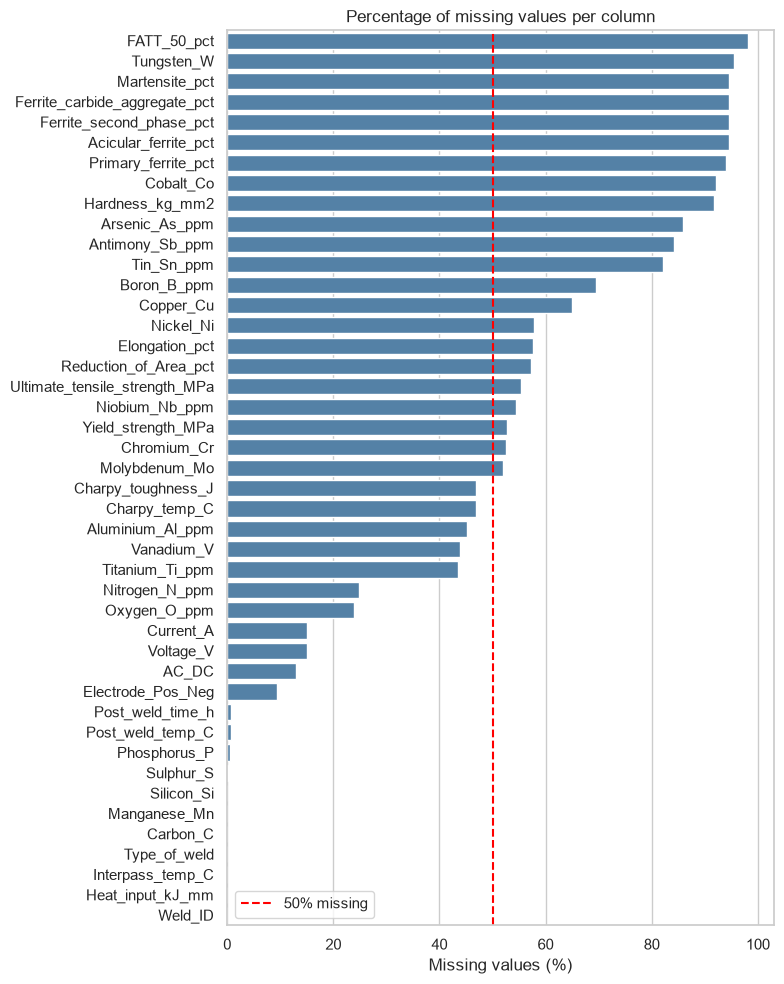

Rows with at least one missing value: 1652 / 1652
Rows with no missing value:           0 / 1652


In [7]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.axvline(50, color="red", linestyle="--", label="50% missing")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.title("Percentage of missing values per column")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rows with at least one missing value: {df.isna().any(axis=1).sum()} / {len(df)}")
print(f"Rows with no missing value:           {(~df.isna().any(axis=1)).sum()} / {len(df)}")

### 1.4 Descriptive statistics

For this summary only, we build a temporary numeric copy of the data (`df_num`) where non-convertible entries become NaN. The original `df` is left untouched.

In [8]:
df_num = df.copy()
for col in numeric_candidates:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

df_num[numeric_candidates].describe().T

,count,mean,std,min,25%,50%,75%,max
Carbon_C,1652.0,0.075521,0.023898,0.029,0.06175,0.074,0.086,0.18
Silicon_Si,1652.0,0.328577,0.112455,0.040,0.27000,0.320,0.360,1.14
Manganese_Mn,1652.0,1.202821,0.382137,0.270,0.94000,1.270,1.440,2.25
Sulphur_S,1641.0,0.009561,0.011239,0.001,0.00600,0.007,0.010,0.14
Phosphorus_P,1642.0,0.012952,0.019627,0.002,0.00700,0.010,0.014,0.25
Nickel_Ni,697.0,0.415034,0.786951,0.000,0.00000,0.067,0.260,3.50
Chromium_Cr,784.0,2.101273,3.026548,0.000,0.00000,0.530,2.300,10.20
Molybdenum_Mo,791.0,0.480358,0.477423,0.000,0.00000,0.340,1.010,1.50
Vanadium_V,620.0,0.072443,0.096364,0.000,0.00400,0.015,0.180,0.32
Copper_Cu,564.0,0.176188,0.325897,0.000,0.00000,0.030,0.190,1.63


### 1.5 Distributions of numerical variables

We look for skewness, outliers and suspicious repeated values (sentinel or default values).

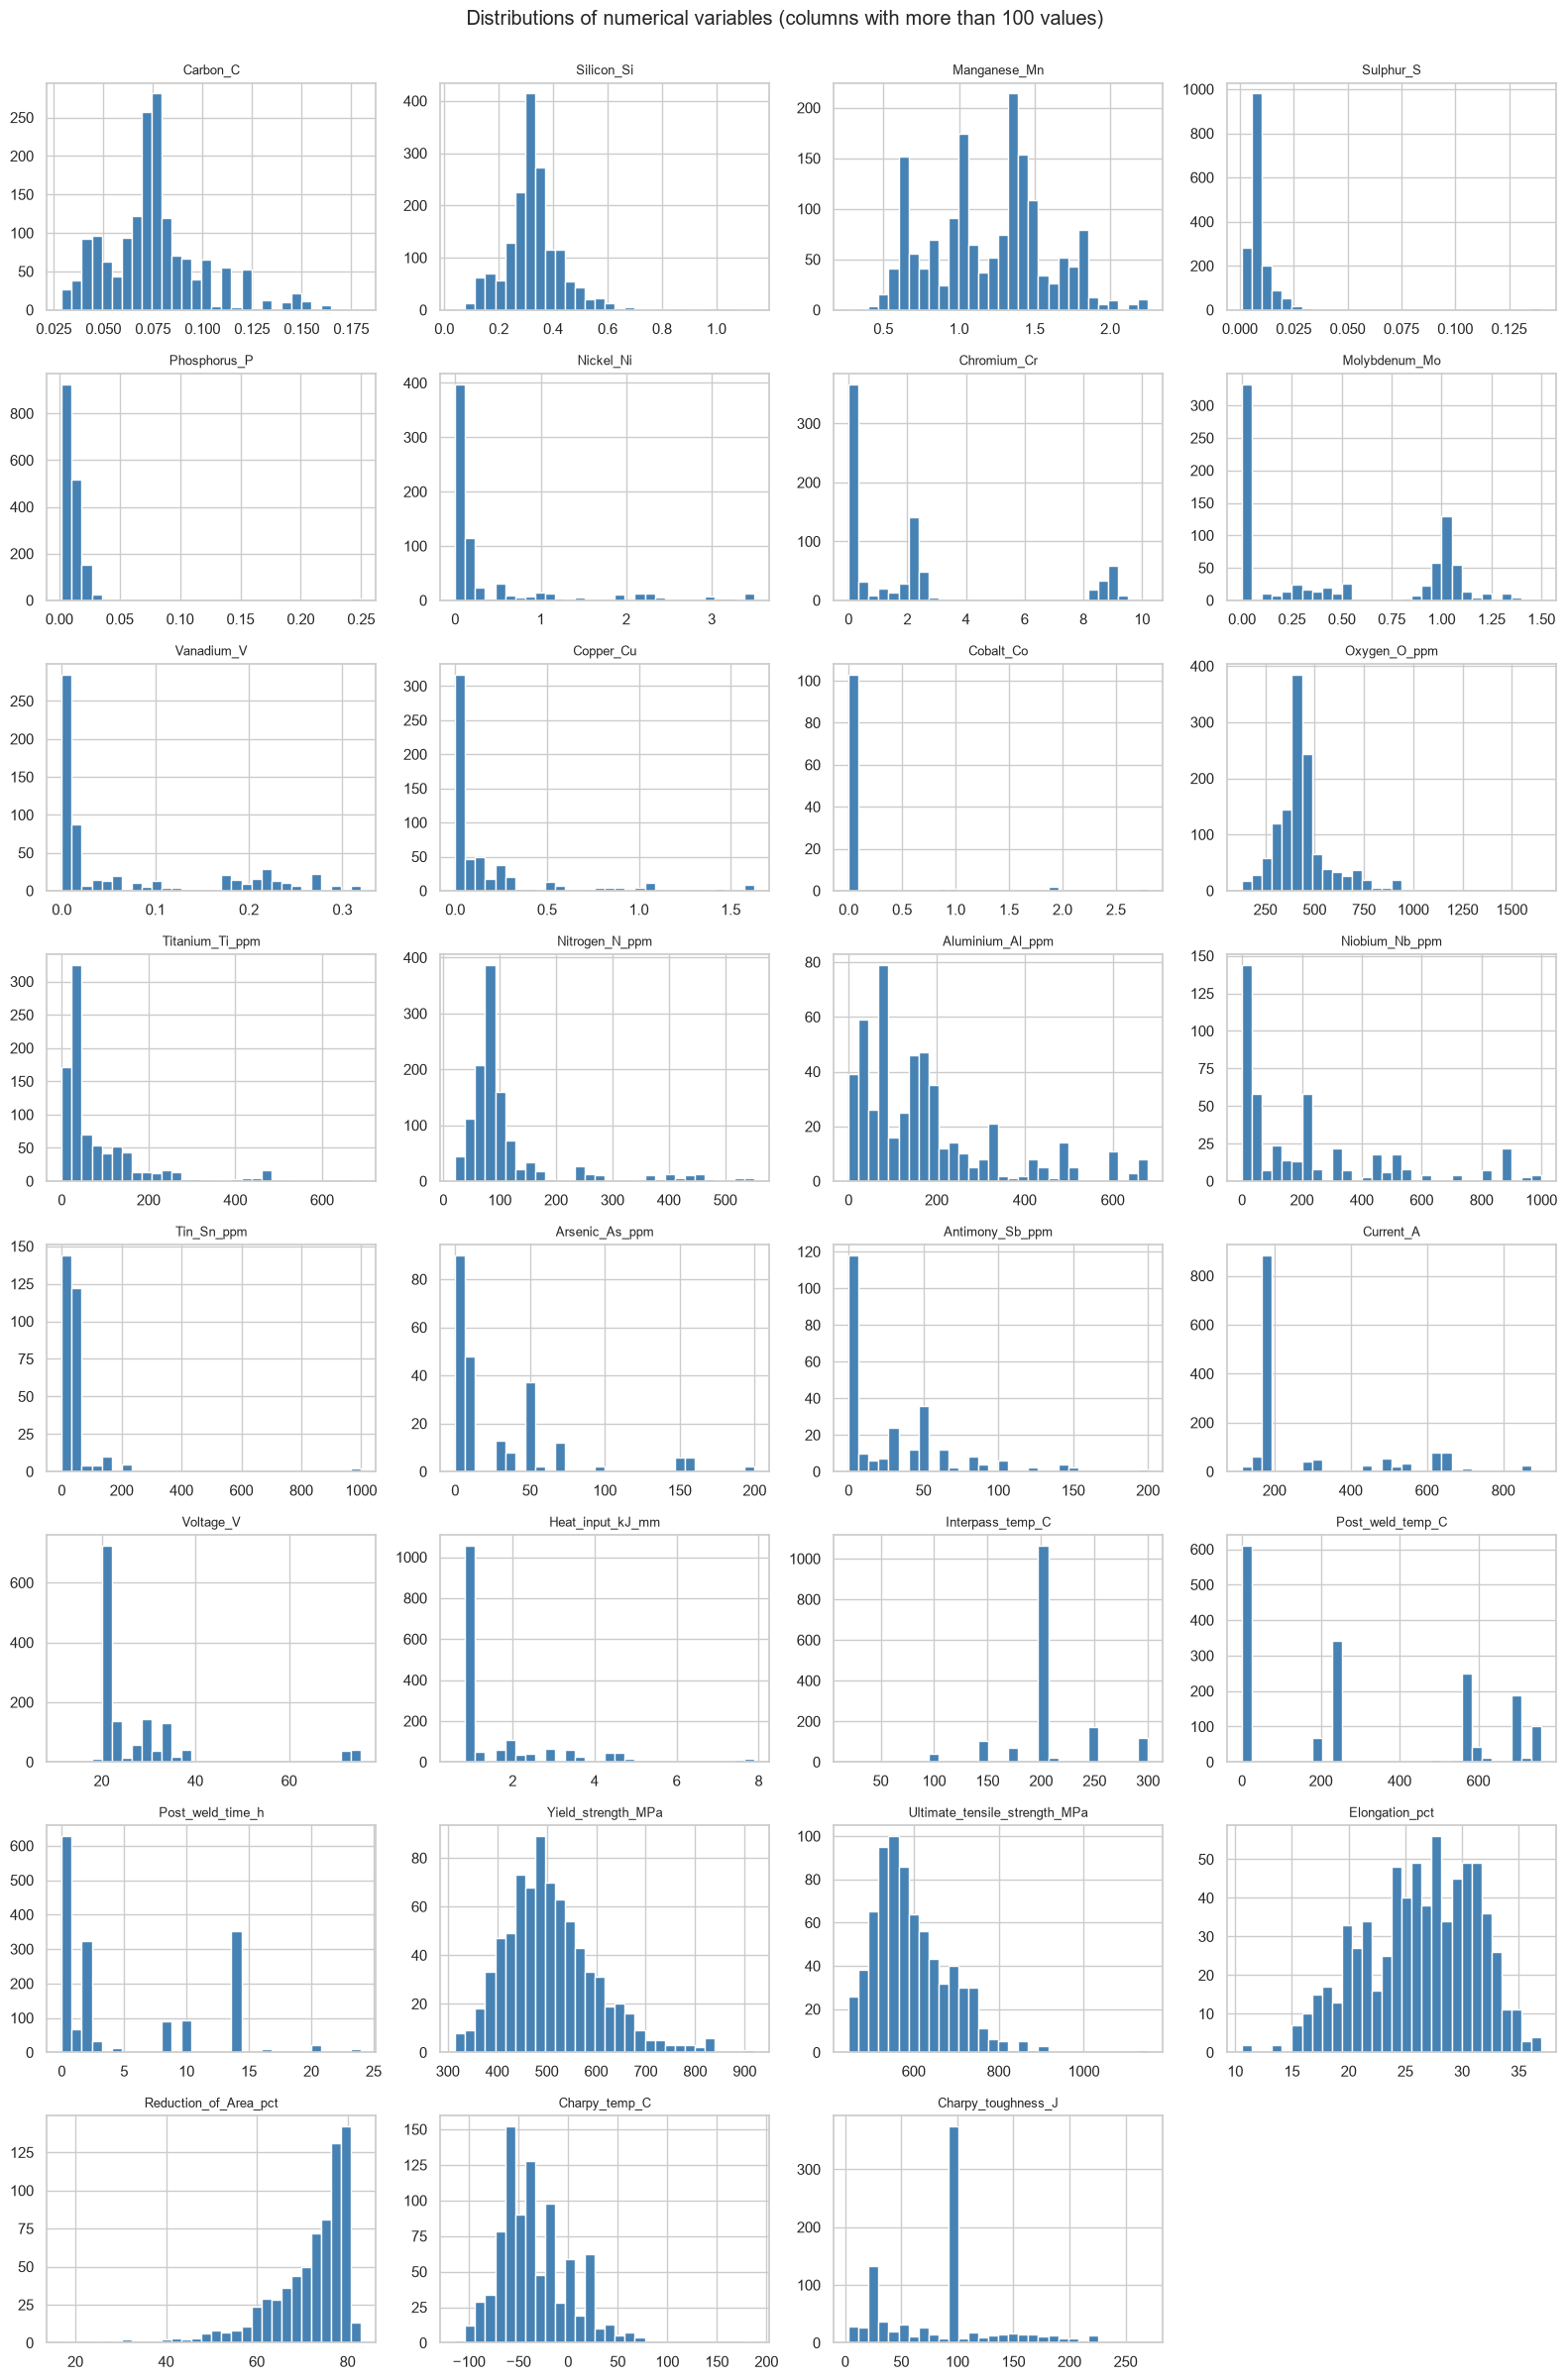

In [9]:
plot_cols = [c for c in numeric_candidates if df_num[c].notna().sum() > 100]

n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df_num[col].dropna(), bins=30, color="steelblue")
    ax.set_title(col, fontsize=9)
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")
plt.suptitle("Distributions of numerical variables (columns with more than 100 values)", y=1.0)
plt.tight_layout()
plt.show()

### 1.6 Categorical variables

In [10]:
for col in ["Type_of_weld", "AC_DC", "Electrode_Pos_Neg"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string(), "\n")

--- Type_of_weld ---
Type_of_weld
MMA      1140
SA        261
FCA        87
TSA        87
ShMA       40
NGSAW      18
NGGMA       7
SAA         4
GTAA        4
GMAA        4 

--- AC_DC ---
AC_DC
DC     1395
NaN     215
AC       42 

--- Electrode_Pos_Neg ---
Electrode_Pos_Neg
+      1451
NaN     156
0        38
-         7 



### 1.7 Candidate target variables

The project asks us to identify which variables represent weld quality. The main candidates are the mechanical properties. We compare how many measurements each one has and how they are distributed.

,n_values,pct_missing,min,median,max
Charpy_toughness_J,879,46.8,3.0,100.0,270.0
Yield_strength_MPa,780,52.8,315.0,495.0,920.0
Ultimate_tensile_strength_MPa,738,55.3,447.0,575.5,1151.0
Elongation_pct,700,57.6,10.6,26.8,37.0
Reduction_of_Area_pct,705,57.3,17.0,75.0,83.0
Hardness_kg_mm2,80,95.2,154.0,221.0,265.0


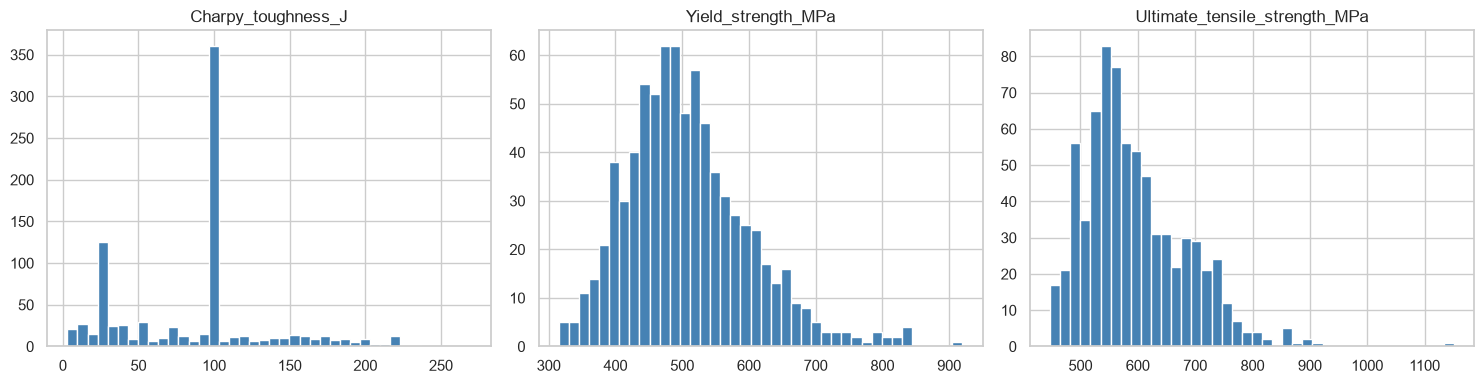

In [11]:
target_candidates = [
    "Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Hardness_kg_mm2",
]

summary = pd.DataFrame({
    "n_values": df_num[target_candidates].notna().sum(),
    "pct_missing": (df_num[target_candidates].isna().mean() * 100).round(1),
    "min": df_num[target_candidates].min(),
    "median": df_num[target_candidates].median(),
    "max": df_num[target_candidates].max(),
})
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa"]):
    ax.hist(df_num[col].dropna(), bins=40, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Charpy_toughness_J` is the energy absorbed by the weld during an impact test, but it depends on the temperature at which the test was done (`Charpy_temp_C`). Below we check that dependence and how many tests were done at each temperature.

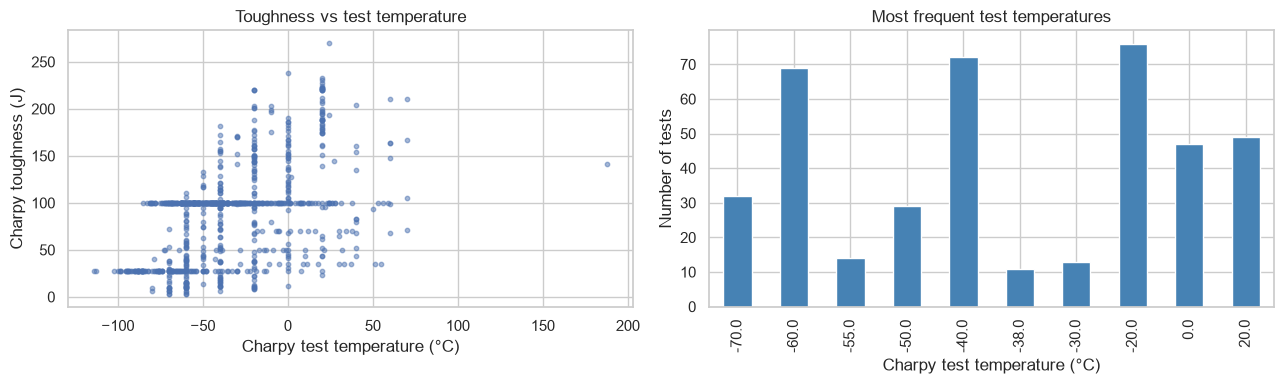

Most frequent toughness values:
Charpy_toughness_J
100.0    356
28.0     118
50.0      16
35.0      12
70.0      12


In [12]:
charpy = df_num[["Charpy_temp_C", "Charpy_toughness_J"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(charpy["Charpy_temp_C"], charpy["Charpy_toughness_J"], s=10, alpha=0.5)
axes[0].set_xlabel("Charpy test temperature (°C)")
axes[0].set_ylabel("Charpy toughness (J)")
axes[0].set_title("Toughness vs test temperature")

charpy["Charpy_temp_C"].value_counts().head(10).sort_index().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_xlabel("Charpy test temperature (°C)")
axes[1].set_ylabel("Number of tests")
axes[1].set_title("Most frequent test temperatures")
plt.tight_layout()
plt.show()

print("Most frequent toughness values:")
print(charpy["Charpy_toughness_J"].value_counts().head(5).to_string())

### 1.8 Correlations

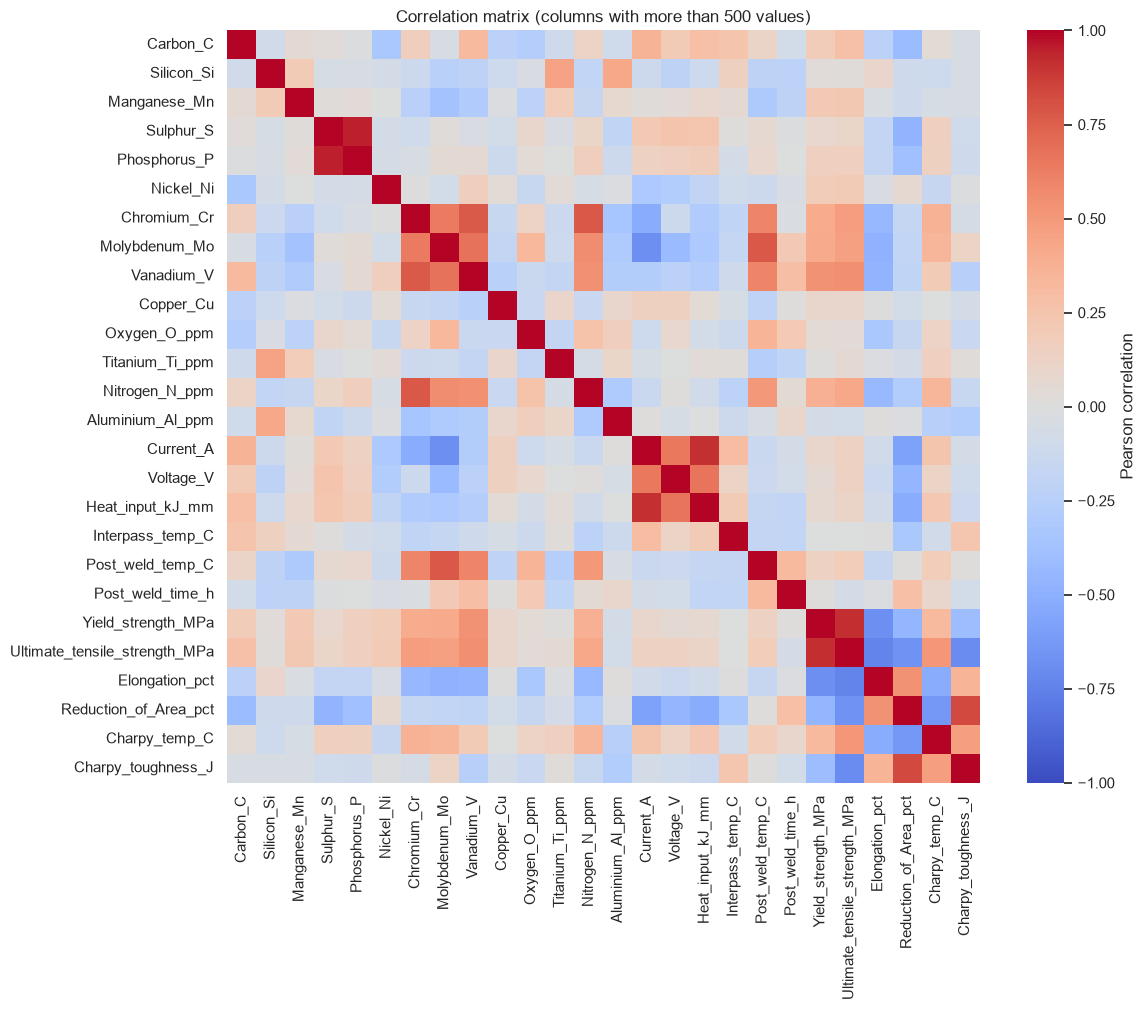

In [13]:
corr_cols = [c for c in numeric_candidates if df_num[c].notna().sum() > 500]
corr = df_num[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix (columns with more than 500 values)")
plt.tight_layout()
plt.show()

### 1.9 Duplicates and weld groups

Several rows can belong to the same weld (same composition and process, different test conditions). This matters for validation: if rows of the same weld land in both train and test sets, the performance is overestimated.

In [14]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Unique Weld_ID values: {df['Weld_ID'].nunique()} / {len(df)}")

# Same composition and process parameters shared by several rows
composition_cols = ["Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
                    "Current_A", "Voltage_V", "Heat_input_kJ_mm"]
group_sizes = df.groupby(composition_cols, dropna=False).size()
print(f"Distinct composition/process combinations: {len(group_sizes)}")
print(f"Rows per combination: median {group_sizes.median():.0f}, max {group_sizes.max()}")

Fully duplicated rows: 0
Unique Weld_ID values: 1490 / 1652
Distinct composition/process combinations: 609
Rows per combination: median 2, max 20
